# Vectorized Grid Search Analysis

Analyse results from the vectorized (σ₀, σ, η) parameter sweep.

Data lives in per-slice `.npz` files (`grid_slice_s0idxN.npz`) and a master
`grid_search_results_vec.npz`. Per-triple raw data (hit/FA scores, ROC
curves) is stored in `per_triple/`.

Plots (all stratified by **top / middle / bottom 15 %** of triples):
1. ISI decay curves
2. Parameter sensitivity (marginal d′ curves)
3. ROC curves per ISI
4. Hit vs FA score distributions
5. Parameter value distributions by group

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── Point this to your vectorized grid-search output directory ──
RESULTS_DIR = '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/2d_grid_search_vectorized_dense'

# Load master grid arrays
grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results_vec.npz'))
sigma0_grid = grid['sigma0_grid']
sigma_grid  = grid['sigma_grid']
eta_grid    = grid['eta_grid']
ISI_VALUES  = tuple(grid['isi_values'].astype(int))

# 3-D d' arrays: shape (n_s0, n_sig, n_eta)
results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

print(f'Grid: {len(sigma0_grid)} x {len(sigma_grid)} x {len(eta_grid)} '
      f'= {len(sigma0_grid)*len(sigma_grid)*len(eta_grid)} triples')
print(f'ISI values: {ISI_VALUES}')
print(f'sigma0: {sigma0_grid}')
print(f'sigma:  {sigma_grid}')
print(f'eta:    {eta_grid}')

Grid: 25 x 25 x 20 = 12500 triples
ISI values: (0, 2, 8, 16)
sigma0: [1.00000000e-04 1.46779927e-04 2.15443469e-04 3.16227766e-04
 4.64158883e-04 6.81292069e-04 1.00000000e-03 1.46779927e-03
 2.15443469e-03 3.16227766e-03 4.64158883e-03 6.81292069e-03
 1.00000000e-02 1.46779927e-02 2.15443469e-02 3.16227766e-02
 4.64158883e-02 6.81292069e-02 1.00000000e-01 1.46779927e-01
 2.15443469e-01 3.16227766e-01 4.64158883e-01 6.81292069e-01
 1.00000000e+00]
sigma:  [1.00000000e-04 1.39598275e-04 1.94876784e-04 2.72044630e-04
 3.79769610e-04 5.30151826e-04 7.40082804e-04 1.03314283e-03
 1.44224957e-03 2.01335552e-03 2.81060958e-03 3.92356250e-03
 5.47722558e-03 7.64611243e-03 1.06738411e-02 1.49004980e-02
 2.08008382e-02 2.90376114e-02 4.05360046e-02 5.65875633e-02
 7.89952623e-02 1.10276024e-01 1.53943427e-01 2.14902369e-01
 3.00000000e-01]
eta:    [1.00000000e-04 1.49189556e-04 2.22575236e-04 3.32059005e-04
 4.95397355e-04 7.39081113e-04 1.10263183e-03 1.64501153e-03
 2.45418539e-03 3.66138828e

## Build flat table of triples & assign percentile groups

Rank every (σ₀, σ, η) triple by its **mean d′ across ISIs**, then
label the top 15 %, middle 15 % (42.5–57.5 %ile), and bottom 15 %.

In [2]:
# Flatten the 3-D grids into a DataFrame
rows = []
for i_s0, s0 in enumerate(sigma0_grid):
    for i_sig, sig in enumerate(sigma_grid):
        for i_eta, eta in enumerate(eta_grid):
            row = {'sigma0': s0, 'sigma': sig, 'eta': eta,
                   'i_s0': i_s0, 'i_sig': i_sig, 'i_eta': i_eta}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = results[isi][i_s0, i_sig, i_eta]
            rows.append(row)

df = pd.DataFrame(rows)

# Mean d' across all ISIs
dp_cols = [f'dprime_isi{isi}' for isi in ISI_VALUES]
df['dprime_mean'] = df[dp_cols].mean(axis=1)

# ISI decay (ISI=0 minus ISI=max)
isi_max = max(ISI_VALUES)
df['delta_dp'] = df['dprime_isi0'] - df[f'dprime_isi{isi_max}']

# Percentile rank
df['pct_rank'] = df['dprime_mean'].rank(pct=True)

def assign_group(pct):
    if pct <= 0.15:
        return 'Bottom 15%'
    elif 0.425 <= pct <= 0.575:
        return 'Middle 15%'
    elif pct >= 0.85:
        return 'Top 15%'
    return None

df['group'] = df['pct_rank'].apply(assign_group)
df_grouped = df.dropna(subset=['group'])

GROUP_COLORS = {'Top 15%': '#2ca02c', 'Middle 15%': '#1f77b4', 'Bottom 15%': '#d62728'}
GROUP_ORDER  = ['Top 15%', 'Middle 15%', 'Bottom 15%']

for g in GROUP_ORDER:
    sub = df_grouped[df_grouped['group'] == g]
    print(f"{g}: {len(sub)} triples, mean d' = {sub['dprime_mean'].mean():.3f}")

print(f"\nTotal triples: {len(df)}, grouped: {len(df_grouped)}")

Top 15%: 2019 triples, mean d' = 6.722
Middle 15%: 1050 triples, mean d' = 2.670
Bottom 15%: 1050 triples, mean d' = 1.016

Total triples: 12500, grouped: 4119


## 1. ISI Decay Curves by Percentile Group

Mean d′ ± SEM across ISI for each group. Shows whether top-performing
triples also show more/less memory decay.

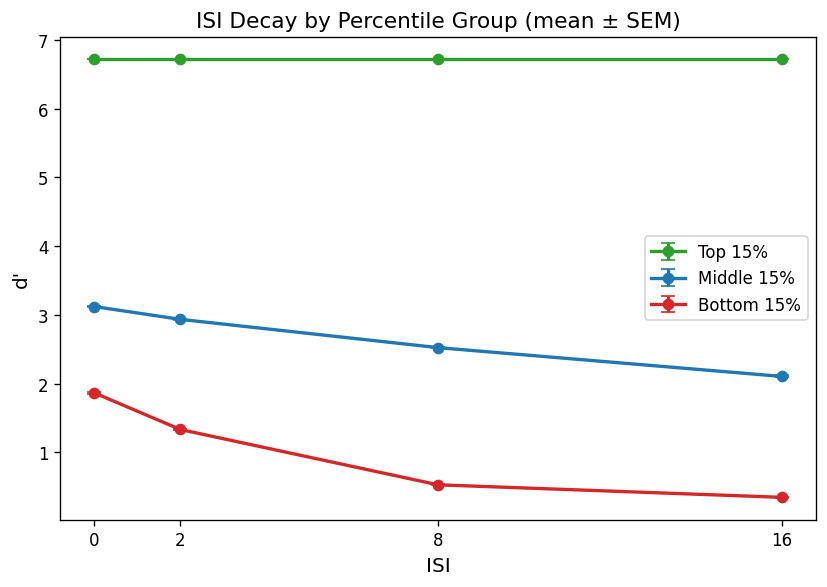

In [3]:
isi_arr = np.array(ISI_VALUES)

fig, ax = plt.subplots(figsize=(7, 5))

for group in GROUP_ORDER:
    sub = df_grouped[df_grouped['group'] == group]
    means = [sub[f'dprime_isi{isi}'].mean() for isi in ISI_VALUES]
    sems  = [sub[f'dprime_isi{isi}'].std() / np.sqrt(len(sub)) for isi in ISI_VALUES]
    ax.errorbar(isi_arr, means, yerr=sems, marker='o', capsize=4,
                color=GROUP_COLORS[group], label=group, linewidth=2)

ax.set_xlabel('ISI', fontsize=12)
ax.set_ylabel("d'", fontsize=12)
ax.set_title('ISI Decay by Percentile Group (mean ± SEM)', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(isi_arr)
fig.tight_layout()
plt.show()

### Individual ISI decay curves within each group

Thin lines = individual triples; thick line = group mean.

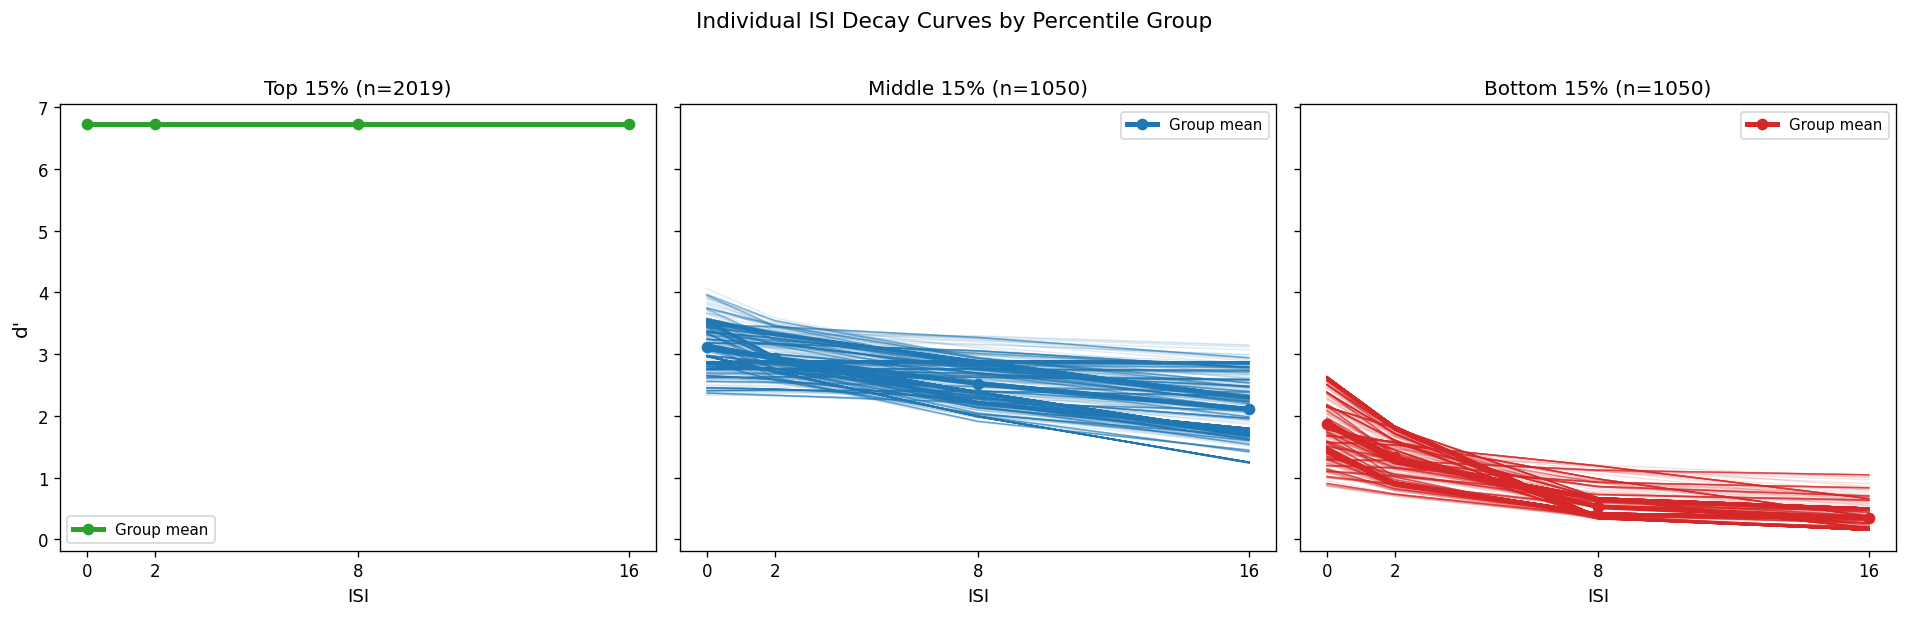

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, group in zip(axes, GROUP_ORDER):
    sub = df_grouped[df_grouped['group'] == group]
    color = GROUP_COLORS[group]

    # Individual traces (thin, transparent)
    for _, row in sub.iterrows():
        dps = [row[f'dprime_isi{isi}'] for isi in ISI_VALUES]
        ax.plot(isi_arr, dps, color=color, alpha=0.15, linewidth=0.8)

    # Group mean (thick)
    means = [sub[f'dprime_isi{isi}'].mean() for isi in ISI_VALUES]
    ax.plot(isi_arr, means, color=color, linewidth=3, marker='o', label='Group mean')

    ax.set_title(f'{group} (n={len(sub)})', fontsize=12)
    ax.set_xlabel('ISI', fontsize=11)
    ax.set_xticks(isi_arr)
    ax.legend(fontsize=9)

axes[0].set_ylabel("d'", fontsize=12)
fig.suptitle('Individual ISI Decay Curves by Percentile Group', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 2. Parameter Sensitivity by Percentile Group

Marginal d′ averaged over the other two parameters, shown separately
for each percentile group and ISI.

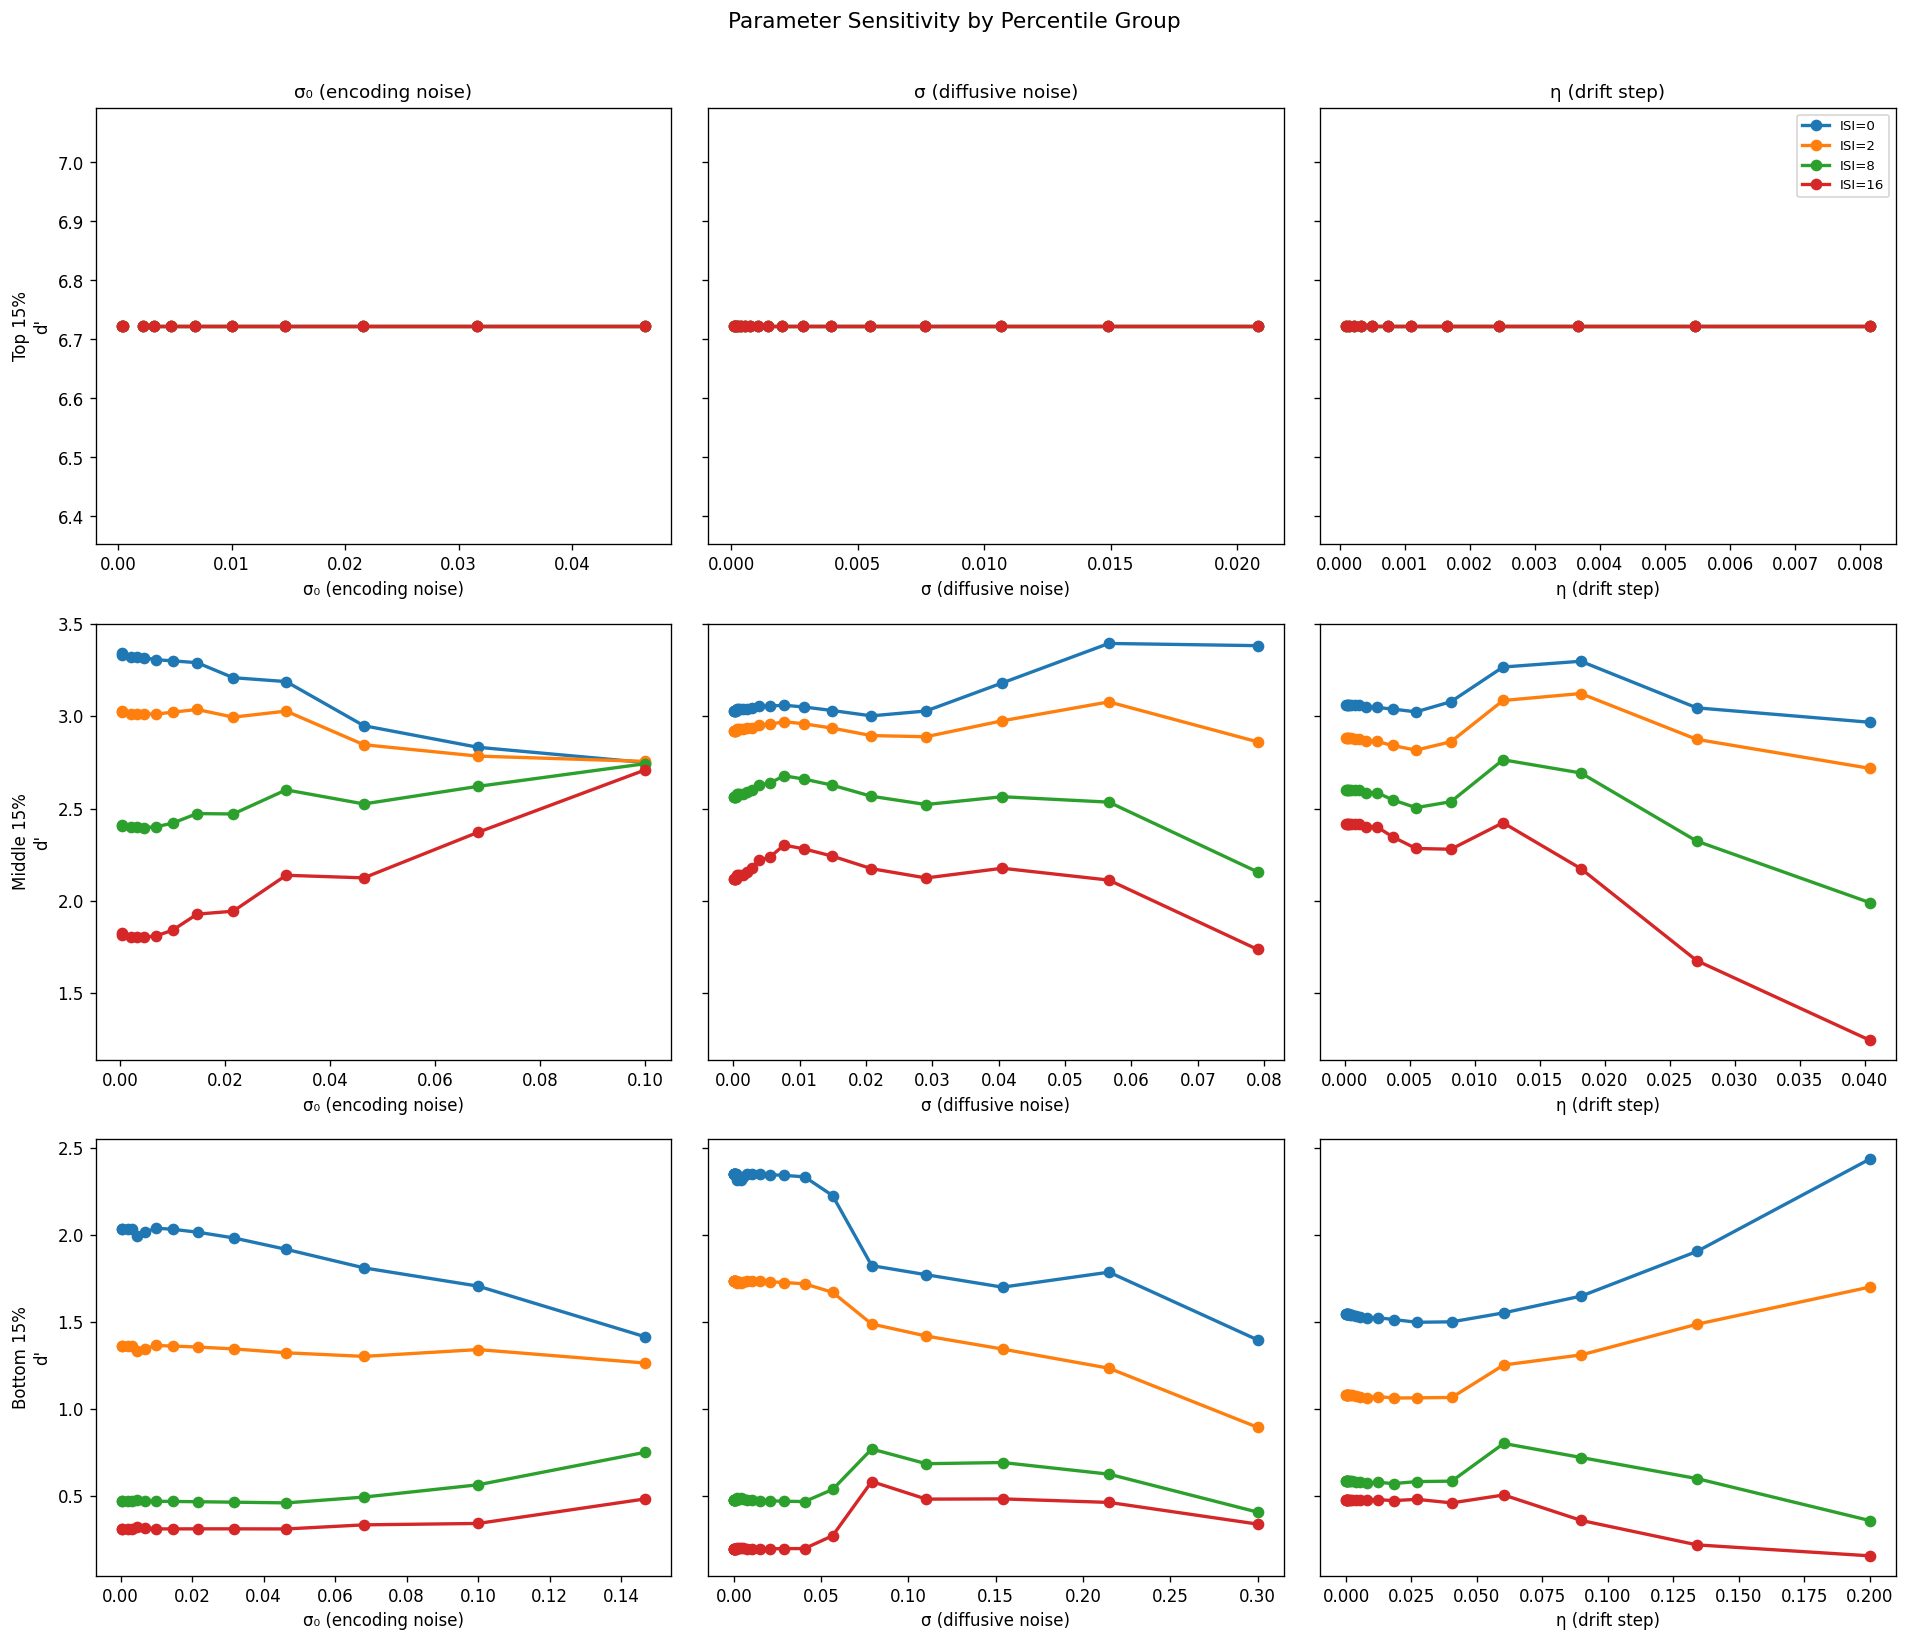

In [5]:
param_info = [
    ('sigma0', 'σ₀ (encoding noise)', sigma0_grid),
    ('sigma',  'σ (diffusive noise)',  sigma_grid),
    ('eta',    'η (drift step)',       eta_grid),
]

fig, axes = plt.subplots(len(GROUP_ORDER), 3, figsize=(16, 4.5 * len(GROUP_ORDER)),
                         sharey='row')

for row_idx, group in enumerate(GROUP_ORDER):
    sub = df_grouped[df_grouped['group'] == group]
    color = GROUP_COLORS[group]

    for col_idx, (pname, plabel, pgrid) in enumerate(param_info):
        ax = axes[row_idx, col_idx]
        for isi in ISI_VALUES:
            means = [sub[sub[pname] == pval][f'dprime_isi{isi}'].mean()
                     for pval in pgrid]
            ax.plot(pgrid, means, 'o-', linewidth=2, label=f'ISI={isi}')

        ax.set_xlabel(plabel, fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(f"{group}\nd'", fontsize=10)
        if row_idx == 0:
            ax.set_title(plabel, fontsize=11)
        if row_idx == 0 and col_idx == 2:
            ax.legend(fontsize=8)

fig.suptitle('Parameter Sensitivity by Percentile Group', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### Overlay: all three groups on one plot per parameter

Uses mean d′ across all ISIs to compare groups directly.

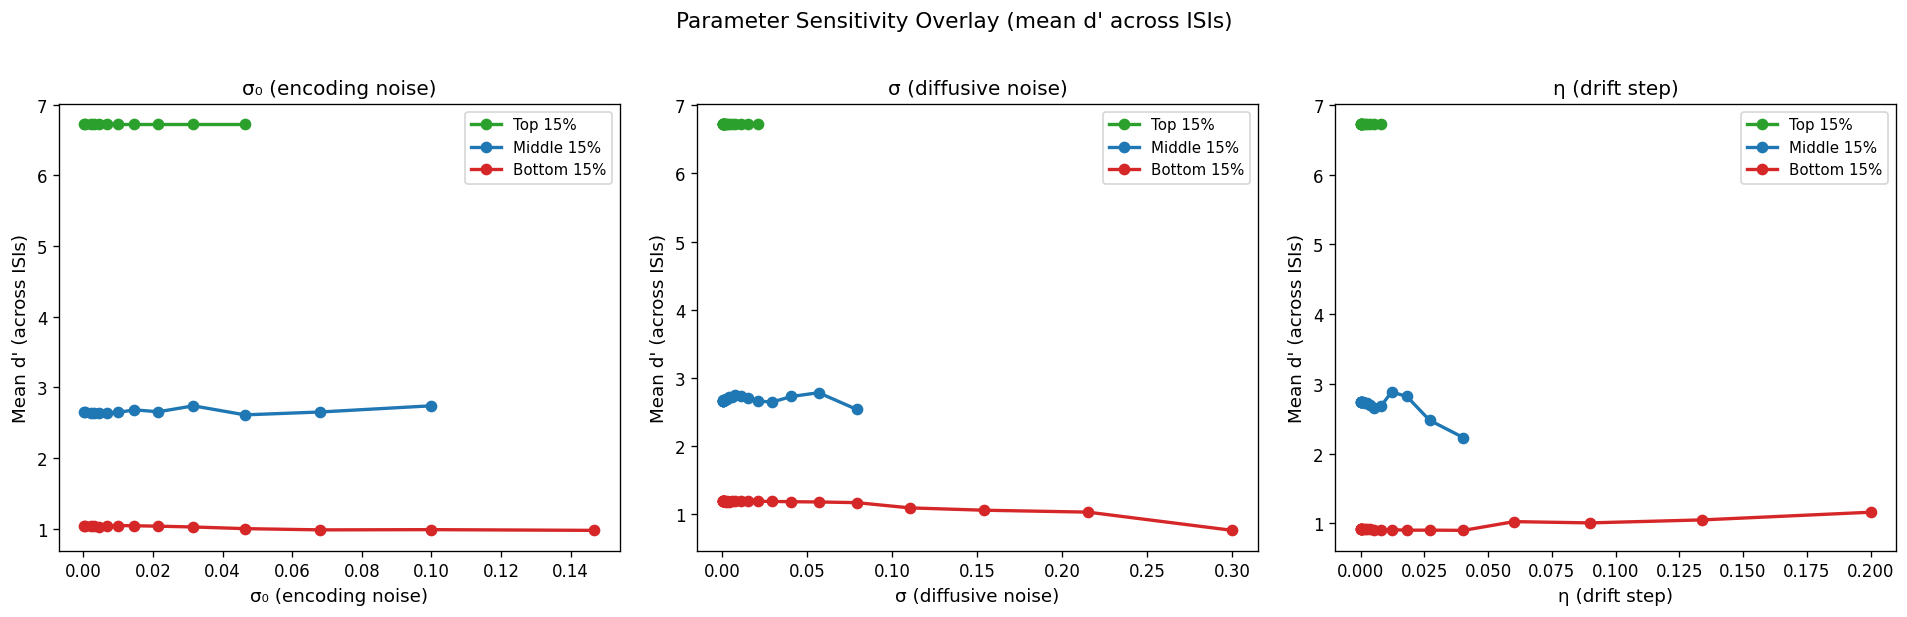

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for col_idx, (pname, plabel, pgrid) in enumerate(param_info):
    ax = axes[col_idx]
    for group in GROUP_ORDER:
        sub = df_grouped[df_grouped['group'] == group]
        means = [sub[sub[pname] == pval]['dprime_mean'].mean() for pval in pgrid]
        ax.plot(pgrid, means, 'o-', linewidth=2,
                color=GROUP_COLORS[group], label=group)
    ax.set_xlabel(plabel, fontsize=11)
    ax.set_ylabel("Mean d' (across ISIs)", fontsize=11)
    ax.set_title(plabel, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle('Parameter Sensitivity Overlay (mean d\' across ISIs)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 3. Best and Worst Triples

Show the parameter combinations in each percentile group.

In [7]:
show_cols = ['sigma0', 'sigma', 'eta'] + dp_cols + ['dprime_mean', 'delta_dp']

for group in GROUP_ORDER:
    sub = df_grouped[df_grouped['group'] == group].sort_values('dprime_mean', ascending=False)
    print(f'\n=== {group} (n={len(sub)}) ===')
    print(sub[show_cols].head(10).to_string(index=False, float_format='%.3f'))


=== Top 15% (n=2019) ===
 sigma0  sigma   eta  dprime_isi0  dprime_isi2  dprime_isi8  dprime_isi16  dprime_mean  delta_dp
  0.046  0.011 0.001        6.722        6.722        6.722         6.722        6.722     0.000
  0.000  0.000 0.000        6.722        6.722        6.722         6.722        6.722     0.000
  0.000  0.000 0.000        6.722        6.722        6.722         6.722        6.722     0.000
  0.046  0.003 0.000        6.722        6.722        6.722         6.722        6.722     0.000
  0.046  0.003 0.000        6.722        6.722        6.722         6.722        6.722     0.000
  0.046  0.003 0.001        6.722        6.722        6.722         6.722        6.722     0.000
  0.046  0.003 0.001        6.722        6.722        6.722         6.722        6.722     0.000
  0.046  0.003 0.002        6.722        6.722        6.722         6.722        6.722     0.000
  0.046  0.003 0.002        6.722        6.722        6.722         6.722        6.722     0.000
  0.

## 4. ISI Decay vs Overall Performance

Scatter of Δd′ (ISI=0 minus ISI=max) vs mean d′. Do better triples
show more or less decay?

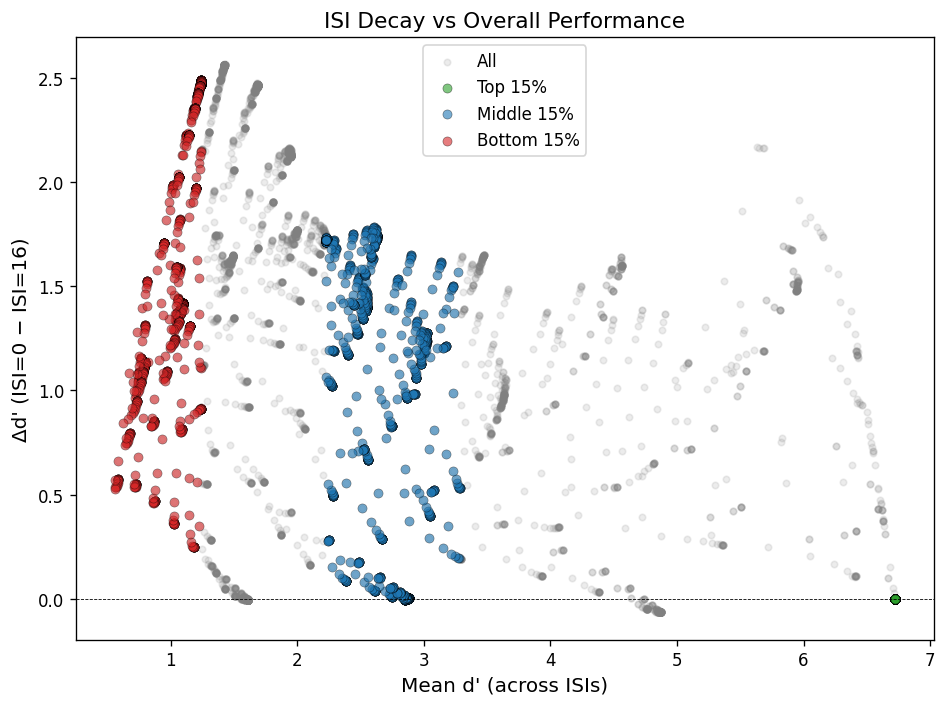

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

# All triples (background)
ax.scatter(df['dprime_mean'], df['delta_dp'], alpha=0.15, s=15, color='gray', label='All')

# Grouped triples
for group in GROUP_ORDER:
    sub = df_grouped[df_grouped['group'] == group]
    ax.scatter(sub['dprime_mean'], sub['delta_dp'], alpha=0.6, s=30,
               color=GROUP_COLORS[group], label=group, edgecolors='k', linewidth=0.3)

ax.set_xlabel("Mean d' (across ISIs)", fontsize=12)
ax.set_ylabel(f"Δd' (ISI=0 − ISI={isi_max})", fontsize=12)
ax.set_title('ISI Decay vs Overall Performance', fontsize=13)
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

---

## 5. ROC Curves by Percentile Group

ROC (FPR vs TPR) per ISI, overlaid for sampled triples within each
percentile group. Requires per-triple `.npz` files in `per_triple/`.

In [9]:
PER_TRIPLE_DIR = os.path.join(RESULTS_DIR, 'per_triple')
HAS_PER_TRIPLE = os.path.isdir(PER_TRIPLE_DIR)

def load_triple(s0, sig, eta):
    """Load a per-triple npz file."""
    fname = f's0={s0:.3f}_sig={sig:.3f}_eta={eta:.3f}.npz'
    return np.load(os.path.join(PER_TRIPLE_DIR, fname), allow_pickle=True)

if HAS_PER_TRIPLE:
    print(f'Per-triple data found at {PER_TRIPLE_DIR}')
    print(f'  Files: {len(os.listdir(PER_TRIPLE_DIR))}')
else:
    print('⚠ No per-triple directory found. ROC and distribution plots will be skipped.')
    print(f'  Expected: {PER_TRIPLE_DIR}')

Per-triple data found at /orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/2d_grid_search_vectorized_dense/per_triple
  Files: 3290


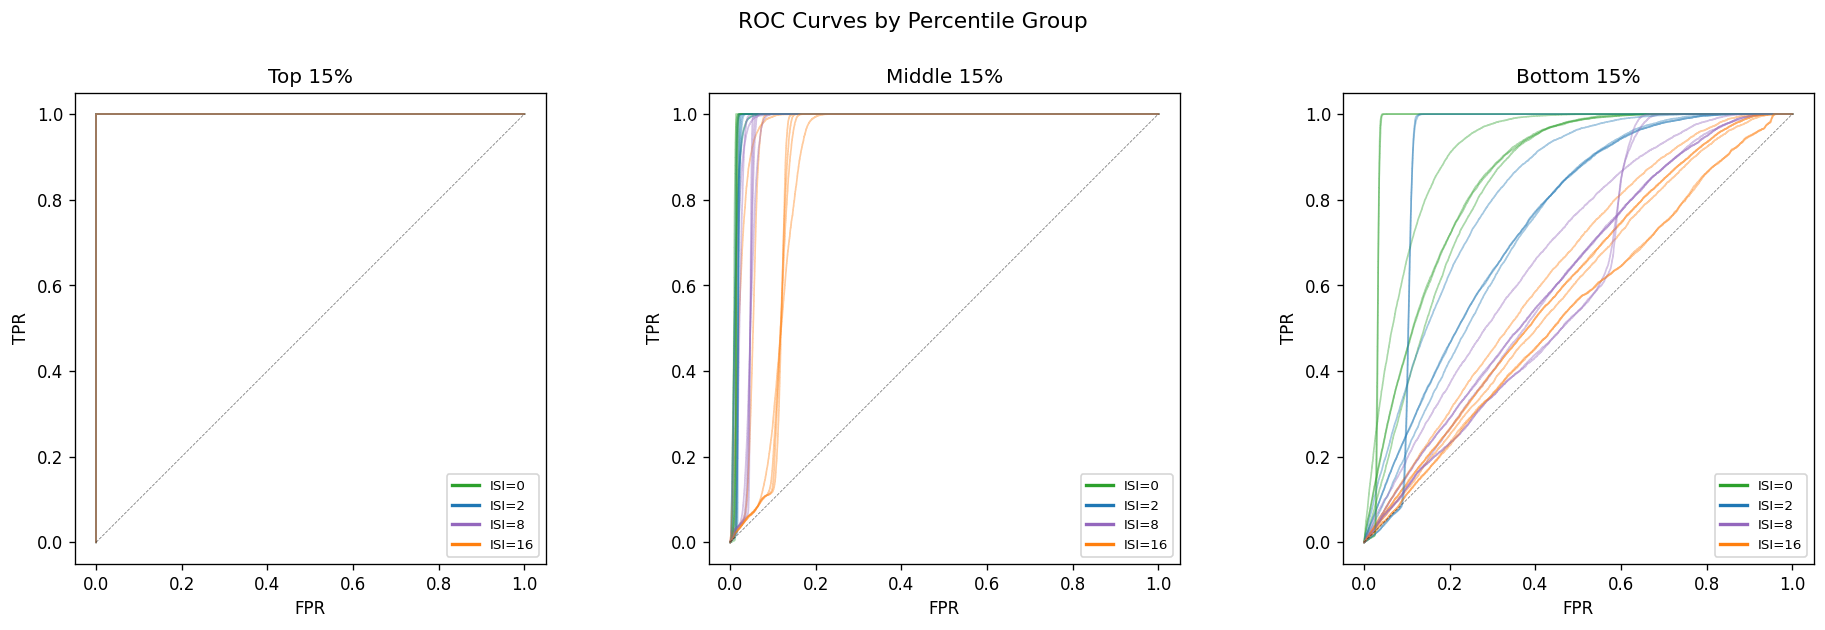

In [10]:
if HAS_PER_TRIPLE:
    isi_colors = {0: '#2ca02c', 2: '#1f77b4', 8: '#9467bd', 16: '#ff7f0e'}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, group in zip(axes, GROUP_ORDER):
        sub = df_grouped[df_grouped['group'] == group]
        # Pick a representative sample (up to 6 triples)
        sample = sub.sample(n=min(6, len(sub)), random_state=42)

        for _, row in sample.iterrows():
            try:
                data = load_triple(row['sigma0'], row['sigma'], row['eta'])
            except FileNotFoundError:
                continue
            for isi in ISI_VALUES:
                fpr_key = f'roc_fpr_isi{isi}'
                tpr_key = f'roc_tpr_isi{isi}'
                auc_key = f'auc_isi{isi}'
                if fpr_key in data and len(data[fpr_key]) > 0:
                    ax.plot(data[fpr_key], data[tpr_key],
                            color=isi_colors.get(isi, 'gray'), alpha=0.4, linewidth=1)

        # Legend entries (one per ISI)
        for isi in ISI_VALUES:
            ax.plot([], [], color=isi_colors.get(isi, 'gray'), linewidth=2,
                    label=f'ISI={isi}')

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5, alpha=0.5)
        ax.set_title(group, fontsize=12)
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.set_aspect('equal')
        ax.legend(fontsize=8)

    fig.suptitle('ROC Curves by Percentile Group', fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print('Skipped: no per-triple data available.')

## 6. Score Distributions by Percentile Group

Hit vs FA score histograms, one panel per group.
Pools scores across sampled triples within each percentile group.

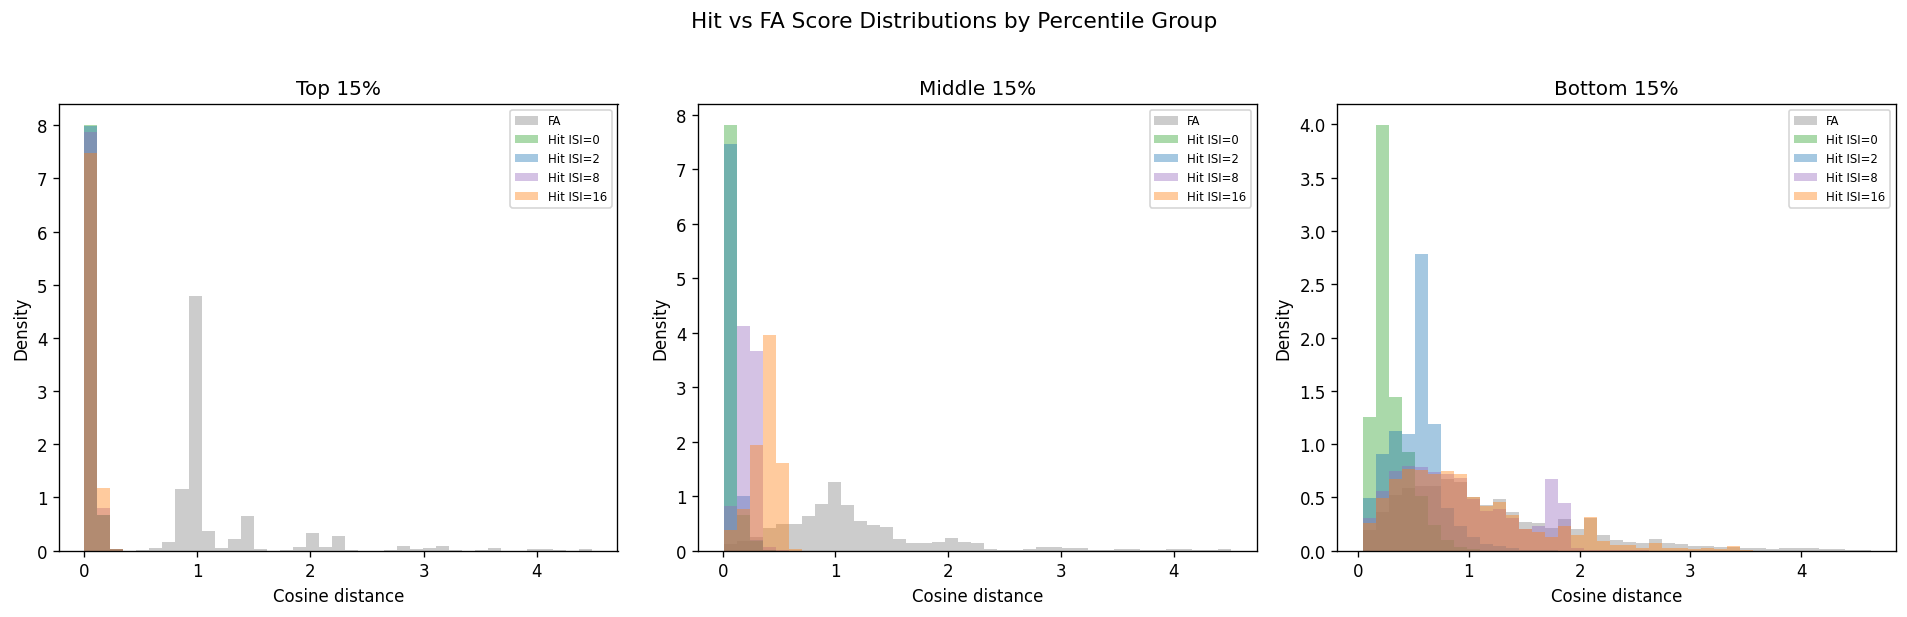

In [11]:
if HAS_PER_TRIPLE:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, group in zip(axes, GROUP_ORDER):
        sub = df_grouped[df_grouped['group'] == group]
        sample = sub.sample(n=min(6, len(sub)), random_state=42)

        # Pool scores across sampled triples for this group
        fa_pool = []
        hit_pools = {isi: [] for isi in ISI_VALUES}

        for _, row in sample.iterrows():
            try:
                data = load_triple(row['sigma0'], row['sigma'], row['eta'])
            except FileNotFoundError:
                continue
            if 'fa_scores' in data:
                fa_pool.append(data['fa_scores'])
            for isi in ISI_VALUES:
                k = f'hit_scores_isi{isi}'
                if k in data and len(data[k]) > 0:
                    hit_pools[isi].append(data[k])

        if not fa_pool:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            continue

        fa_all = np.concatenate(fa_pool)
        all_scores = [fa_all]
        for isi in ISI_VALUES:
            if hit_pools[isi]:
                all_scores.append(np.concatenate(hit_pools[isi]))
        combined = np.concatenate(all_scores)
        bins = np.linspace(np.percentile(combined, 1), np.percentile(combined, 99), 40)

        ax.hist(fa_all, bins=bins, alpha=0.4, color='gray', label='FA', density=True)
        for isi in ISI_VALUES:
            if hit_pools[isi]:
                h = np.concatenate(hit_pools[isi])
                ax.hist(h, bins=bins, alpha=0.4,
                        color=isi_colors.get(isi, 'gray'),
                        label=f'Hit ISI={isi}', density=True)

        ax.set_title(group, fontsize=12)
        ax.set_xlabel('Cosine distance')
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)

    fig.suptitle('Hit vs FA Score Distributions by Percentile Group', fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print('Skipped: no per-triple data available.')

## 7. Parameter Distributions by Group

Which σ₀, σ, η values are over-represented in each percentile group?

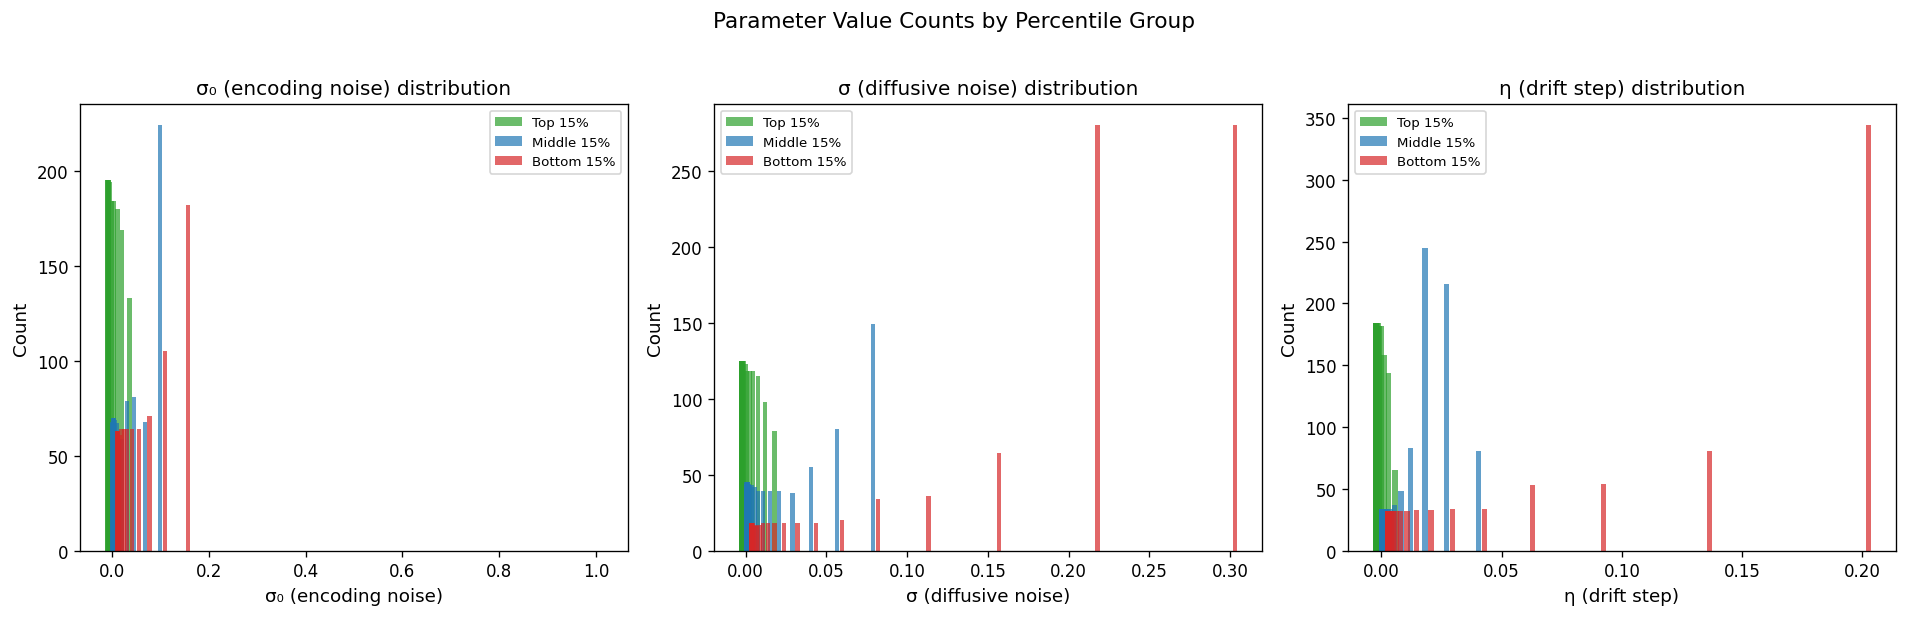

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (pname, plabel, pgrid) in zip(axes, param_info):
    width = (pgrid[-1] - pgrid[0]) / len(pgrid) / (len(GROUP_ORDER) + 1)

    for gi, group in enumerate(GROUP_ORDER):
        sub = df_grouped[df_grouped['group'] == group]
        counts = [len(sub[sub[pname] == pval]) for pval in pgrid]
        offsets = pgrid + (gi - 1) * width
        ax.bar(offsets, counts, width=width * 0.9,
               color=GROUP_COLORS[group], alpha=0.7, label=group)

    ax.set_xlabel(plabel, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{plabel} distribution', fontsize=12)
    ax.legend(fontsize=8)

fig.suptitle('Parameter Value Counts by Percentile Group', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## Summary Statistics

In [ ]:
print('=== Summary by Group ===')
summary = df_grouped.groupby('group').agg(
    n=('dprime_mean', 'count'),
    dprime_mean_avg=('dprime_mean', 'mean'),
    dprime_mean_std=('dprime_mean', 'std'),
    delta_dp_avg=('delta_dp', 'mean'),
    sigma0_median=('sigma0', 'median'),
    sigma_median=('sigma', 'median'),
    eta_median=('eta', 'median'),
).loc[GROUP_ORDER]
print(summary.to_string(float_format='%.3f'))

print('\n=== Overall best triple ===')
best = df.loc[df['dprime_mean'].idxmax()]
print(f"σ₀={best['sigma0']:.3f}, σ={best['sigma']:.3f}, η={best['eta']:.3f}")
for isi in ISI_VALUES:
    print(f"  ISI={isi}: d' = {best[f'dprime_isi{isi}']:.3f}")